<a href="https://colab.research.google.com/github/deyanannya03/Deep_learning_projects/blob/main/Lyrics_generator.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

 #
 1. Importing modules

In [15]:
import tensorflow as tf
from tensorflow.keras.utils import pad_sequences
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, Bidirectional
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam
from tensorflow.keras import regularizers
import matplotlib.pyplot as plt
import numpy as np

2. Input and Preprocessing

In [24]:
tokenizer = Tokenizer()
data="""You got that James Dean daydream look in your eye \n
And I got that red lip classic thing that you like \n
Cause we never go out of style, we never go out of style \n
You got that long hair, slicked back, white T-shirt \n
And I got that good-girl faith and a tight little skirt \n
And when we go crashing down, we come back every time \n
Cause we never go out of style, we never go out of style

Here comes the sun, do do do do
Here comes the sun, and I say
It's all right
Little darling, it's been a long cold lonely winter
Little darling, it feels like years since it's been here
Here comes the sun, do do do do
Here comes the sun, and I say
It's all right

Is this the real life?
Is this just fantasy?
Caught in a landslide,
No escape from reality.
Open your eyes,
Look up to the skies and see,
I'm just a poor boy, I need no sympathy,
Because I'm easy come, easy go,
Little high, little low,
Anyway the wind blows doesn't really matter to me, to me.

"""
corpus=data.lower().split("\n")
tokenizer.fit_on_texts(corpus)
total_words=len(tokenizer.word_index)+1
print(tokenizer.word_index)
print(total_words)

{'do': 1, 'and': 2, 'the': 3, 'we': 4, 'go': 5, 'that': 6, 'i': 7, 'little': 8, 'here': 9, 'got': 10, 'never': 11, 'out': 12, 'of': 13, 'style': 14, 'a': 15, 'comes': 16, 'sun': 17, "it's": 18, 'you': 19, 'to': 20, 'look': 21, 'in': 22, 'your': 23, 'like': 24, 'cause': 25, 'long': 26, 'back': 27, 'come': 28, 'say': 29, 'all': 30, 'right': 31, 'darling': 32, 'been': 33, 'is': 34, 'this': 35, 'just': 36, 'no': 37, "i'm": 38, 'easy': 39, 'me': 40, 'james': 41, 'dean': 42, 'daydream': 43, 'eye': 44, 'red': 45, 'lip': 46, 'classic': 47, 'thing': 48, 'hair': 49, 'slicked': 50, 'white': 51, 't': 52, 'shirt': 53, 'good': 54, 'girl': 55, 'faith': 56, 'tight': 57, 'skirt': 58, 'when': 59, 'crashing': 60, 'down': 61, 'every': 62, 'time': 63, 'cold': 64, 'lonely': 65, 'winter': 66, 'it': 67, 'feels': 68, 'years': 69, 'since': 70, 'real': 71, 'life': 72, 'fantasy': 73, 'caught': 74, 'landslide': 75, 'escape': 76, 'from': 77, 'reality': 78, 'open': 79, 'eyes': 80, 'up': 81, 'skies': 82, 'see': 83, '

In [17]:
input_sequence=[]
for line in corpus:
  token_list=tokenizer.texts_to_sequences([line])[0]
  for i in range(1,len(token_list)):
    n_gram_sequence=token_list[:i+1]
    input_sequence.append(n_gram_sequence)

In [18]:
#pad sequence
max_sequence_len=max(len(x) for x in input_sequence)
input_sequence=np.array(pad_sequences(input_sequence,maxlen=max_sequence_len,padding='pre'))

In [19]:
#create predictors and label
xs,labels=input_sequence[:,:-1],input_sequence[:,-1]
ys=tf.keras.utils.to_categorical(labels,num_classes=total_words)

3. Model creation

In [20]:
model=Sequential()
model.add(Embedding(total_words,100,input_length=max_sequence_len-1))
model.add(Bidirectional(LSTM(150,return_sequences=True)))
model.add(Dropout(0.2))
model.add(LSTM(100))
model.add(Dense(total_words,activation='softmax'))
model.compile(loss='categorical_crossentropy',optimizer='adam',metrics=['accuracy'])
history=model.fit(xs,ys,epochs=100,verbose=1)
print(model.summary())

Epoch 1/100


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


6/6 ━━━━━━━━━━━━━━━━━━━━ 6s 55ms/step - accuracy: 0.0299 - loss: 4.5738
Epoch 2/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 54ms/step - accuracy: 0.0419 - loss: 4.5303
Epoch 3/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 0.0419 - loss: 4.4146
Epoch 4/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 54ms/step - accuracy: 0.0419 - loss: 4.3474
Epoch 5/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - accuracy: 0.0778 - loss: 4.2403
Epoch 6/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 54ms/step - accuracy: 0.0778 - loss: 4.1188
Epoch 7/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - accuracy: 0.0898 - loss: 3.9957
Epoch 8/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 53ms/step - accuracy: 0.0958 - loss: 3.8559
Epoch 9/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - accuracy: 0.1198 - loss: 3.7329
Epoch 10/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 0.1377 - loss: 3.6269
Epoch 11/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 0.1976 - loss: 3.4764
Epoch 12/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - accuracy: 0.1737 - loss: 3.3791
E

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 12, 100)        │         9,700 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 12, 300)        │       301,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 12, 300)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 100)            │       160,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 97)             │         9,797 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,443,293 (5.51 MB)

 Trainable params: 481,097 (1.84 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 962,196 (3.67 MB)

None


4. Plotting the graph

In [21]:
import matplotlib.pyplot as plt
def plot_graphs(history, string):
  plt.plot(history.history[string])
  plt.xlabel("Epochs")
  plt.ylabel(string)
  plt.show()

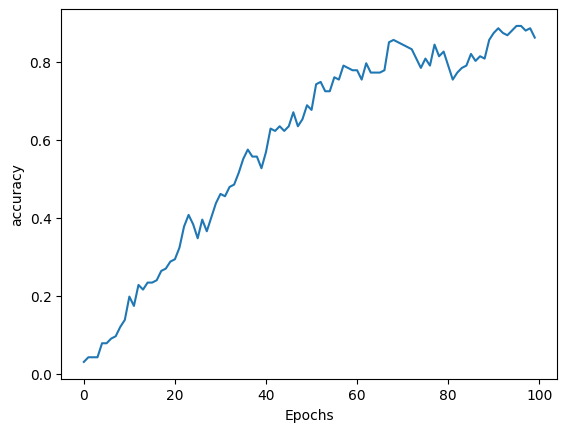

In [22]:
plot_graphs(history, 'accuracy')


5. Prediction test

In [23]:
seed_text="Fever dream high in the quiet"
next_words=100
for _ in range(next_words):
    token_list=tokenizer.texts_to_sequences([seed_text])[0]
    token_list=pad_sequences([token_list],maxlen=max_sequence_len-1,padding='pre')
    predicted=np.argmax(model.predict(token_list,verbose=0),axis=1)
    output_word=""
    for word,index in tokenizer.word_index.items():
        if index==predicted:
            output_word=word
            break
    seed_text+=" "+output_word # Added a space for readability
print(seed_text)

Fever dream high in the quiet it like hair since winter winter eye skirt skirt skirt we skirt of we of we go out of style we never go out of style we never go out of style we never go out of style we never go out of style we never go out of style we never go out of style we never go out of style we never go out of style we never go out of style we never go out of style we never go out of style we never go out of style we never go out of style we never
